# Image Classification (MNIST)

**Goal:**
Classify handwritten digits (0 to 9) from images.

### Importing Dependencies

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
from PIL import Image
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC 
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

#### Loading Data

In [2]:
mnist = fetch_openml('mnist_784', version = 1, parser = 'auto')

X = mnist.data.astype('float32')
y = mnist.target.astype('int')
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


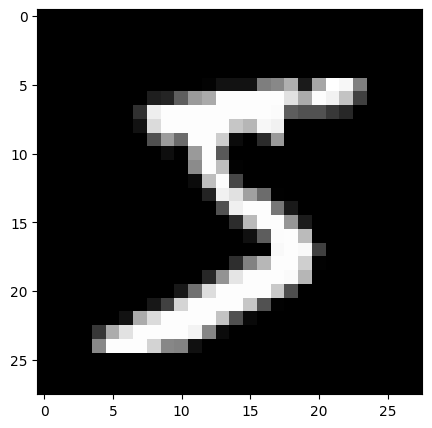

In [3]:
plt.figure(figsize = (12, 5))
plt.imshow(X.iloc[0].values.reshape(28, 28), cmap = 'gray')
plt.show()

#### Data Preprocessing

In [4]:
X_normalized = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size = 0.3, random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Modelling

In [5]:
start = time.time()

lr = LogisticRegression(max_iter = 200, solver = 'saga', n_jobs = -1, random_state = 42)
lr.fit(X_train_scaled, y_train)

train_time = time.time() - start

y_pred = lr.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f'Training Time: {train_time:.2f}s')
print(f'Accuracy: {accuracy:.4f}')
print(f'Class Performance\n{classification_report(y_test, y_pred)}')

Training Time: 285.27s
Accuracy: 0.9208
Class Performance
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      2058
           1       0.92      0.97      0.95      2364
           2       0.93      0.90      0.92      2133
           3       0.91      0.89      0.90      2176
           4       0.91      0.94      0.93      1936
           5       0.90      0.88      0.89      1915
           6       0.94      0.96      0.95      2088
           7       0.92      0.94      0.93      2248
           8       0.91      0.85      0.88      1992
           9       0.90      0.90      0.90      2090

    accuracy                           0.92     21000
   macro avg       0.92      0.92      0.92     21000
weighted avg       0.92      0.92      0.92     21000



C:\Users\bisht\jupyter_env\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [6]:
start = time.time()

rfc = RandomForestClassifier(n_estimators = 200, max_depth = 20, n_jobs = -1, random_state = 42)

rfc.fit(X_train_scaled, y_train)
y_pred2 = rfc.predict(X_test_scaled)
accuracy2 = accuracy_score(y_test, y_pred2)

print(f'Training Time: {train_time:.2f}s')
print(f'Accuracy: {accuracy2:.4f}')
print(f'Class Performance\n{classification_report(y_test, y_pred2)}')

Training Time: 285.27s
Accuracy: 0.9658
Class Performance
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2058
           1       0.98      0.98      0.98      2364
           2       0.95      0.97      0.96      2133
           3       0.96      0.95      0.95      2176
           4       0.97      0.97      0.97      1936
           5       0.97      0.96      0.96      1915
           6       0.98      0.98      0.98      2088
           7       0.97      0.96      0.97      2248
           8       0.96      0.95      0.95      1992
           9       0.95      0.95      0.95      2090

    accuracy                           0.97     21000
   macro avg       0.97      0.97      0.97     21000
weighted avg       0.97      0.97      0.97     21000



In [7]:
start = time.time()

svc = SVC(kernel = 'rbf', gamma = 'scale', random_state = 42)

svc.fit(X_train_scaled, y_train)
y_pred3 = svc.predict(X_test_scaled)
accuracy3 = accuracy_score(y_test, y_pred3)

print(f'Training Time: {train_time:.2f}s')
print(f'Accuracy: {accuracy3:.4f}')
print(f'Class Performance\n{classification_report(y_test, y_pred3)}')

Training Time: 285.27s
Accuracy: 0.9623
Class Performance
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2058
           1       0.98      0.99      0.98      2364
           2       0.95      0.96      0.96      2133
           3       0.96      0.95      0.96      2176
           4       0.96      0.96      0.96      1936
           5       0.97      0.95      0.96      1915
           6       0.97      0.98      0.97      2088
           7       0.92      0.97      0.94      2248
           8       0.97      0.95      0.96      1992
           9       0.96      0.93      0.95      2090

    accuracy                           0.96     21000
   macro avg       0.96      0.96      0.96     21000
weighted avg       0.96      0.96      0.96     21000



#### Model Comparison

In [8]:
models = {
    'Logistic Reg' : (lr, y_pred, accuracy),
    'Random Forest' : (rfc, y_pred2, accuracy2),
    'SVC' : (svc, y_pred3, accuracy3)
}

for name, (model, preds, acc) in models.items():
    print({name})
    print(f'Accuracy: {acc:.4f}\n')

best_name = max(models, key = lambda i: models[i][2])
best_model, best_preds, best_acc = models[best_name]
print(f'\n\nBest Model: {best_name} ({best_acc:.4f})')

{'Logistic Reg'}
Accuracy: 0.9208

{'Random Forest'}
Accuracy: 0.9658

{'SVC'}
Accuracy: 0.9623



Best Model: Random Forest (0.9658)


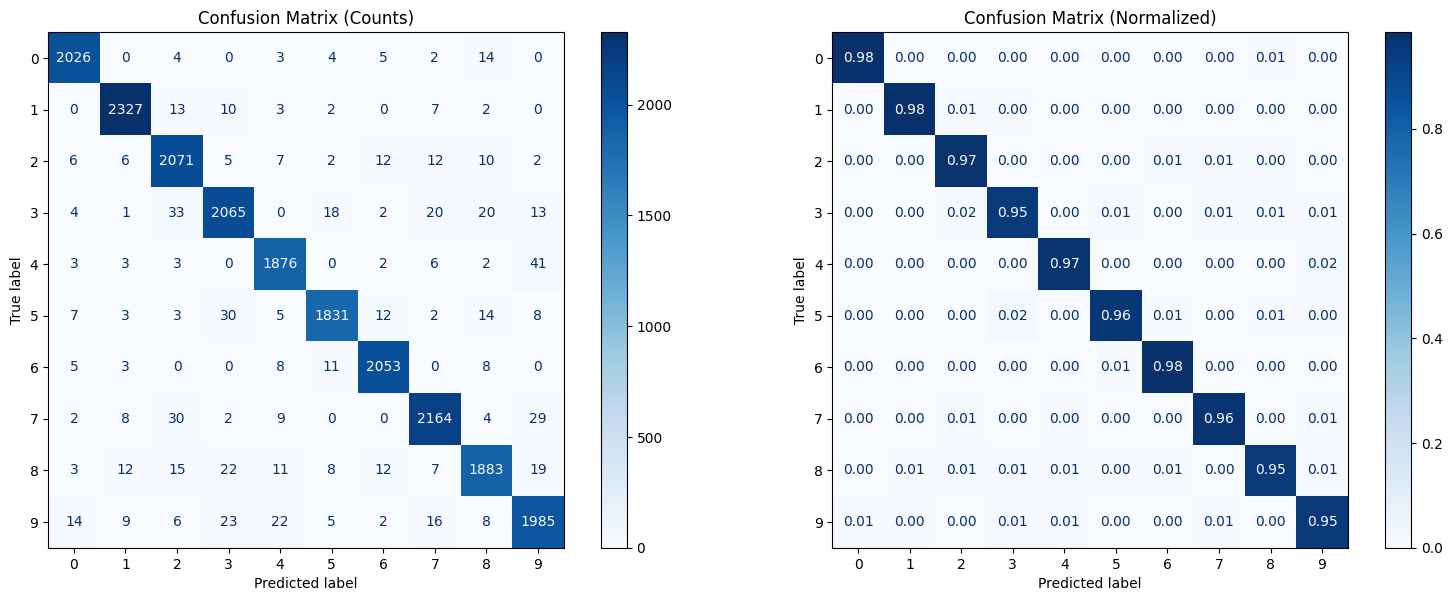

In [9]:
cm = confusion_matrix(y_test, best_preds)

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

graph1 = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = range(10))
graph1.plot(ax = axes[0], cmap = 'Blues', values_format = 'd')
axes[0].set_title('Confusion Matrix (Counts)')

cm_norm = confusion_matrix(y_test, best_preds, normalize = 'true')
graph2 = ConfusionMatrixDisplay(confusion_matrix = cm_norm, display_labels = range(10))
graph2.plot(ax = axes[1], cmap = 'Blues', values_format = '.2f')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.show()

In [10]:
confusions = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > 0:
            confusions.append((cm[i, j], i, j))

confusions.sort(reverse = True)

for count, true_label, pred_label in confusions[: 10]:
    print(f'{count:4d} times: Digit {true_label} predicted as {pred_label}')

  41 times: Digit 4 predicted as 9
  33 times: Digit 3 predicted as 2
  30 times: Digit 7 predicted as 2
  30 times: Digit 5 predicted as 3
  29 times: Digit 7 predicted as 9
  23 times: Digit 9 predicted as 3
  22 times: Digit 9 predicted as 4
  22 times: Digit 8 predicted as 3
  20 times: Digit 3 predicted as 8
  20 times: Digit 3 predicted as 7


#### Visualizing the Errors

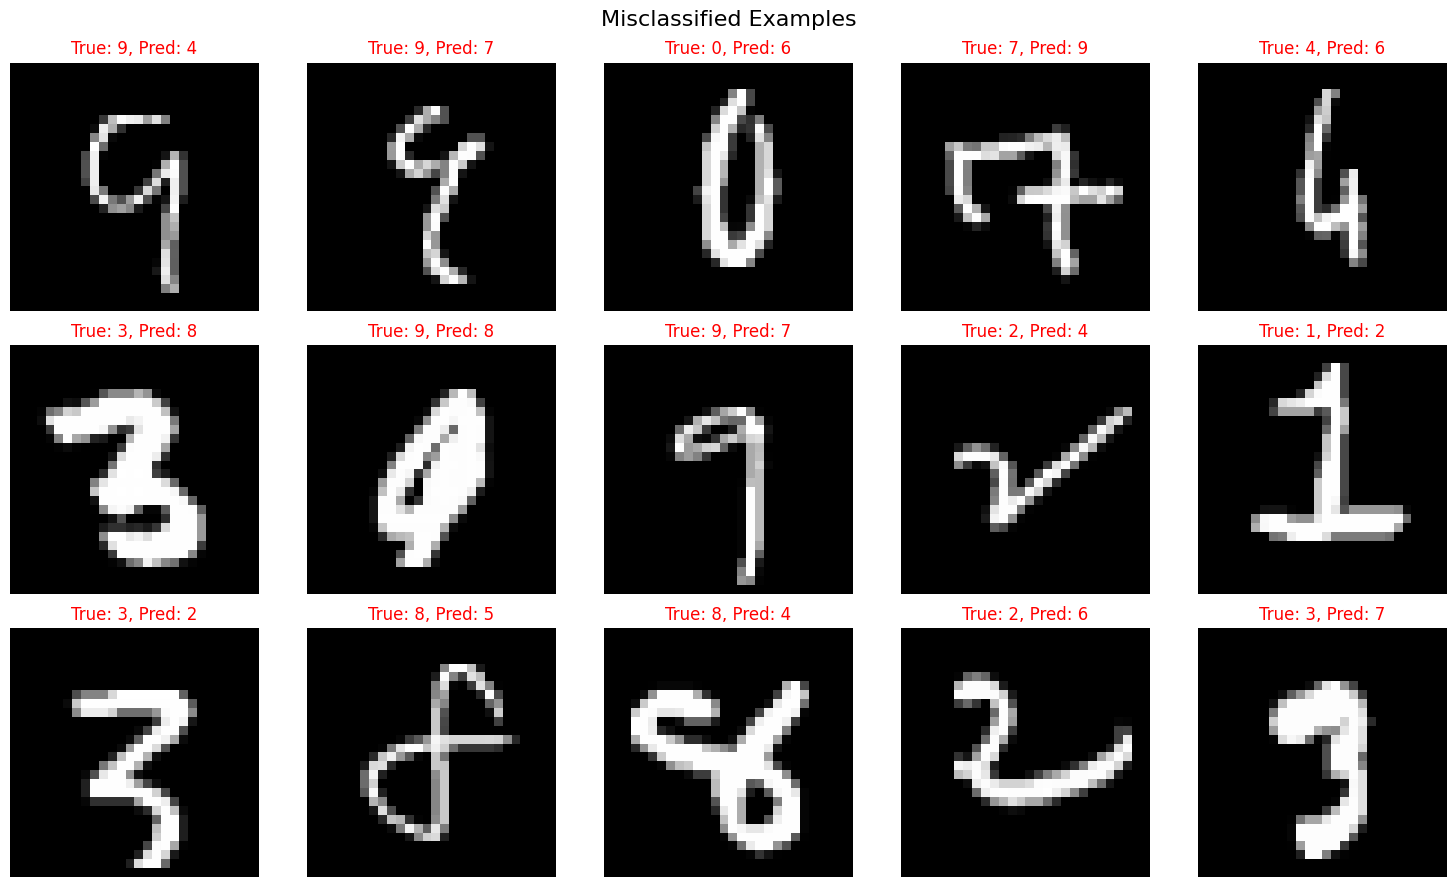


Total errors: 719 out of 21000
Error rate: 3.42%


In [11]:
# Find misclassified examples
errors = y_test != best_preds
error_indices = np.where(errors)[0]
# Visualize some errors
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i, ax in enumerate(axes.flat):
    if i < len(error_indices):
        idx = error_indices[i]
        image = X_test.iloc[idx].values.reshape(28, 28)
        
        ax.imshow(image, cmap='gray')
        ax.set_title(f'True: {y_test.iloc[idx]}, Pred: {best_preds[idx]}', 
                    color='red')
        ax.axis('off')

plt.suptitle('Misclassified Examples', fontsize=16)
plt.tight_layout()
plt.show()

print(f"\nTotal errors: {errors.sum()} out of {len(y_test)}")
print(f"Error rate: {errors.sum() / len(y_test):.2%}")

#### Feature Importance for RFC

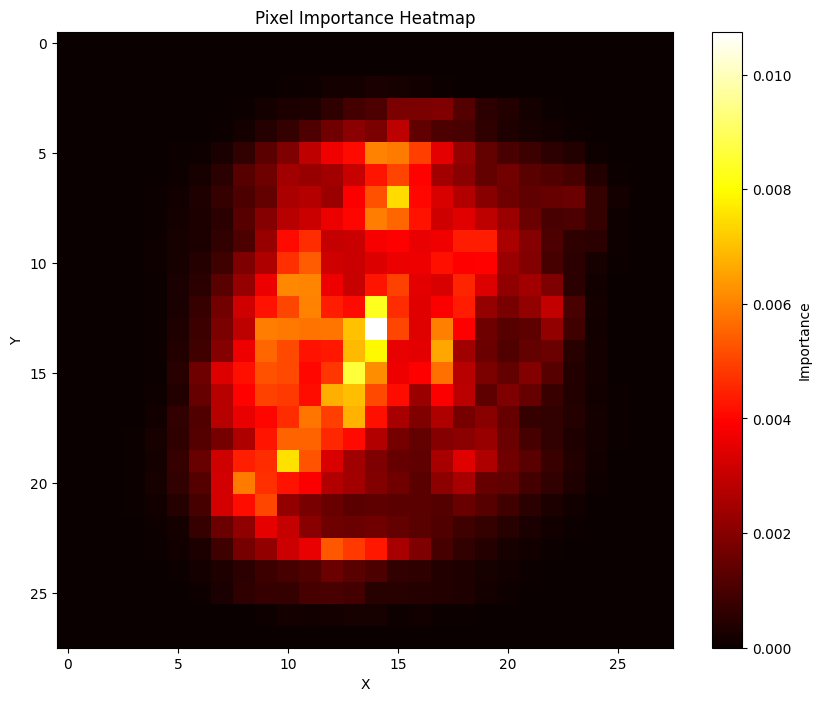


Interpretation:
Bright areas = Important pixels for classification
Dark areas = Less important pixels


In [14]:
if best_name == 'Random Forest':
    importance = best_model.feature_importances_.reshape(28, 28)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(importance, cmap='hot')
    plt.colorbar(label='Importance')
    plt.title('Pixel Importance Heatmap')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.show()
    
    print("\nInterpretation:")
    print("Bright areas = Important pixels for classification")
    print("Dark areas = Less important pixels")

#### Pipeline and Saving Model

In [16]:
image_classifier = Pipeline([
    ('scaler', scaler),
    ('classifier', best_model)
])

# Fit on all training data
image_classifier.fit(X_train, y_train)

# Save
model_info = {
    'pipeline': image_classifier,
    'model_name': best_name,
    'accuracy': best_acc,
    'confusion_matrix': cm.tolist(),
    'version': '1.0.0'
}

joblib.dump(model_info, 'digit_classifier_v1.pkl', compress=3)

print("\nModel saved!")



Model saved!


In [17]:
loaded = joblib.load('digit_classifier_v1.pkl')
pipeline = loaded['pipeline']

test_image = X_test.iloc[0:1]
prediction = pipeline.predict(test_image)[0]
actual = y_test.iloc[0]

print(f"\nTest prediction:")
print(f"Predicted: {prediction}")
print(f"Actual: {actual}")
print(f"Correct: {prediction == actual}")


Test prediction:
Predicted: 8
Actual: 8
Correct: True


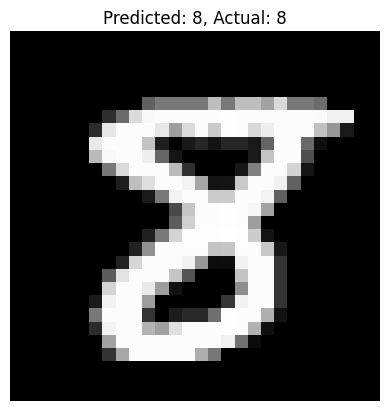

In [18]:
plt.imshow(test_image.values.reshape(28, 28), cmap='gray')
plt.title(f'Predicted: {prediction}, Actual: {actual}')
plt.axis('off')
plt.show()